# Model Evaluation

## Load Experiments CSV & Comparison Per Run

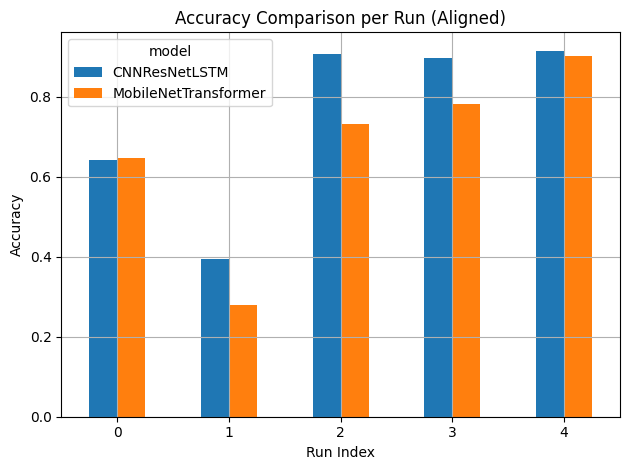

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')

# load csv
df = pd.read_csv("../outputs/metrics/experiments.csv")

# convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# ambil hanya 2 model
models = ["CNNResNetLSTM", "MobileNetTransformer"]
df = df[df['model'].isin(models)]

# sort by timestamp
df = df.sort_values('timestamp')

# kasih index per model (biar sejajar)
df['run_idx'] = df.groupby('model').cumcount()

# pivot
pivot = df.pivot(index='run_idx', columns='model', values='accuracy')

# plot
pivot.plot(kind='bar')

plt.title("Accuracy Comparison per Run (Aligned)")
plt.xlabel("Run Index")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.grid(True)

plt.tight_layout()
plt.show()

## Accuracy Comparison

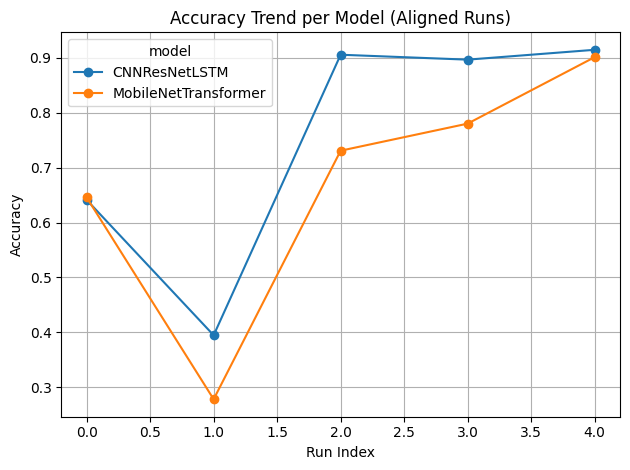

In [7]:
pivot.plot(marker='o')

plt.title("Accuracy Trend per Model (Aligned Runs)")
plt.xlabel("Run Index")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()

## Best Accuracy

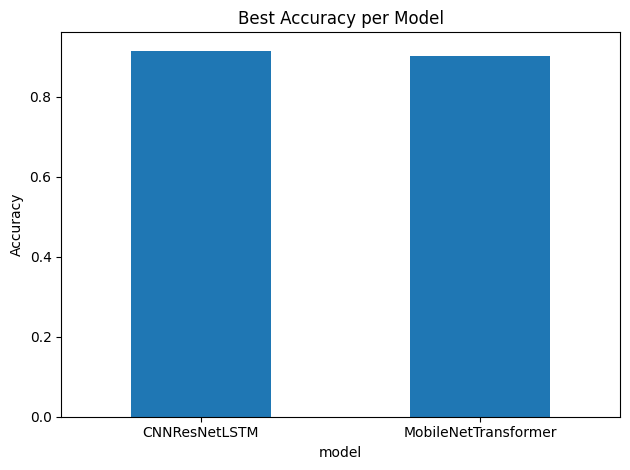

In [8]:
best = df.groupby('model')['accuracy'].max()

best.plot(kind='bar')

plt.title("Best Accuracy per Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Manual Input Model Comparison

In [9]:
def compare_manual(models, accuracies):

    plt.figure(figsize=(6,4))
    plt.bar(models, accuracies)

    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

    plt.title("Manual Model Comparison (Accuracy)")
    plt.ylim(0,1)
    plt.show()

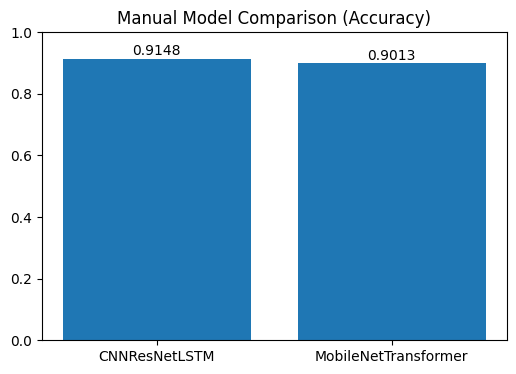

In [10]:
models = ["CNNResNetLSTM", "MobileNetTransformer"]
accuracies = [0.9147982062780269, 0.9013452914798207]

compare_manual(models, accuracies)